In [2]:
import scanpy as sc
import matplotlib.pyplot as plt

print("Scanpy and Matplotlib are working!")


Scanpy and Matplotlib are working!


In [5]:
import scanpy as sc

# Path to your file
file_path = '/mnt/d/scRNA_seq/Ath_roots.tsv'

# Load the dataset using Scanpy
adata = sc.read_text(file_path, delimiter='\t')

# Check the structure of the loaded data
print(adata)


AnnData object with n_obs × n_vars = 21965 × 11030


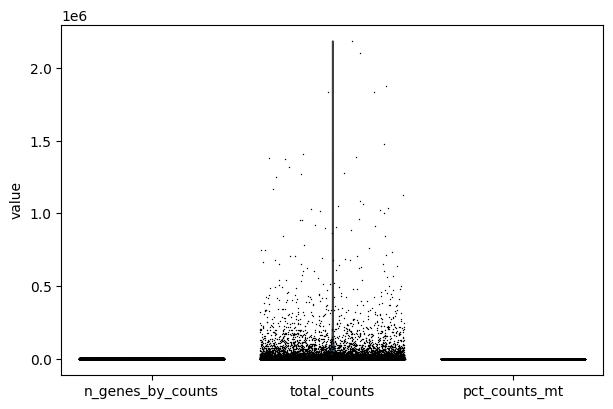

In [6]:
# Identify mitochondrial genes (genes that start with "MT-")
adata.var['mt'] = adata.var_names.str.startswith('MT-')

# Calculate quality control metrics (e.g., gene counts, mitochondrial counts)
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

# Visualize the quality metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4)


In [8]:
# Normalize total counts per cell and log-transform the data
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)  # Logarithmic transformation of the data

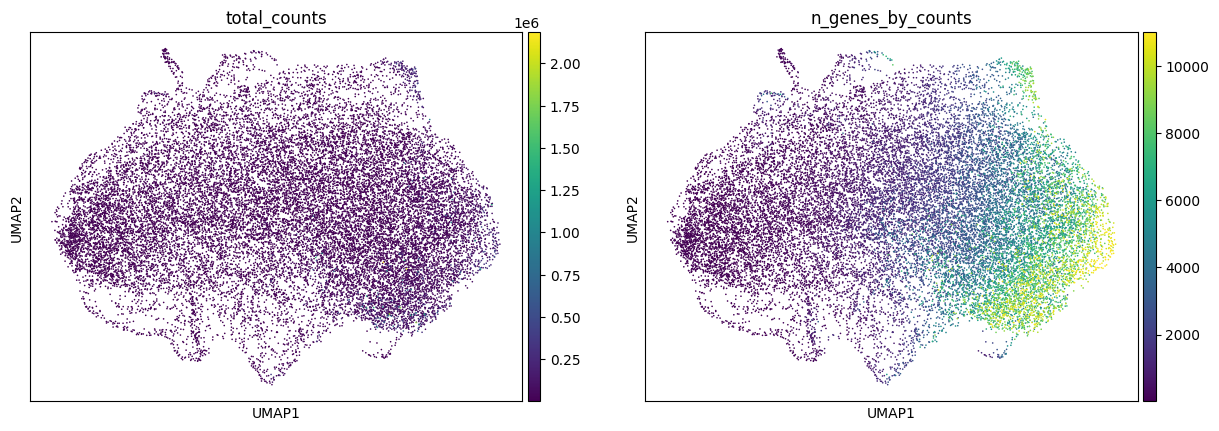

In [9]:
# Perform PCA to reduce dimensionality
sc.tl.pca(adata, svd_solver='arpack')

# Compute the nearest neighbors
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

# Run UMAP for visualization
sc.tl.umap(adata)

# Plot the UMAP, coloring by total counts and gene counts
sc.pl.umap(adata, color=['total_counts', 'n_genes_by_counts'])


In [6]:
import scanpy as sc 

# Cluster cells using the Louvain algorithm
sc.tl.louvain(adata)

# Plot UMAP with clusters (Louvain)
sc.pl.umap(adata, color=['louvain'])


NameError: name 'adata' is not defined

In [11]:
import igraph

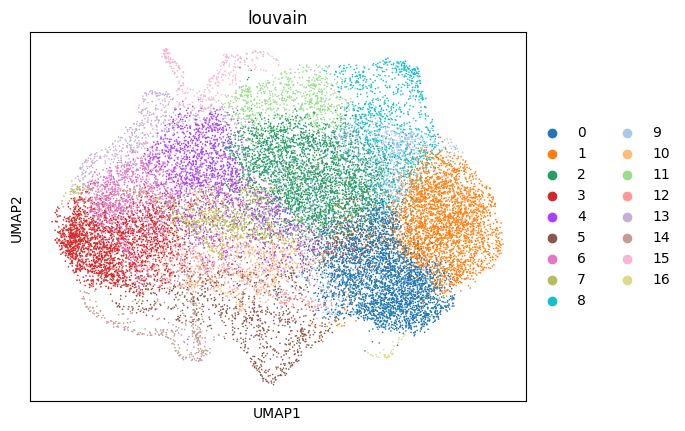

In [12]:
sc.tl.louvain(adata)
sc.pl.umap(adata, color=['louvain'])


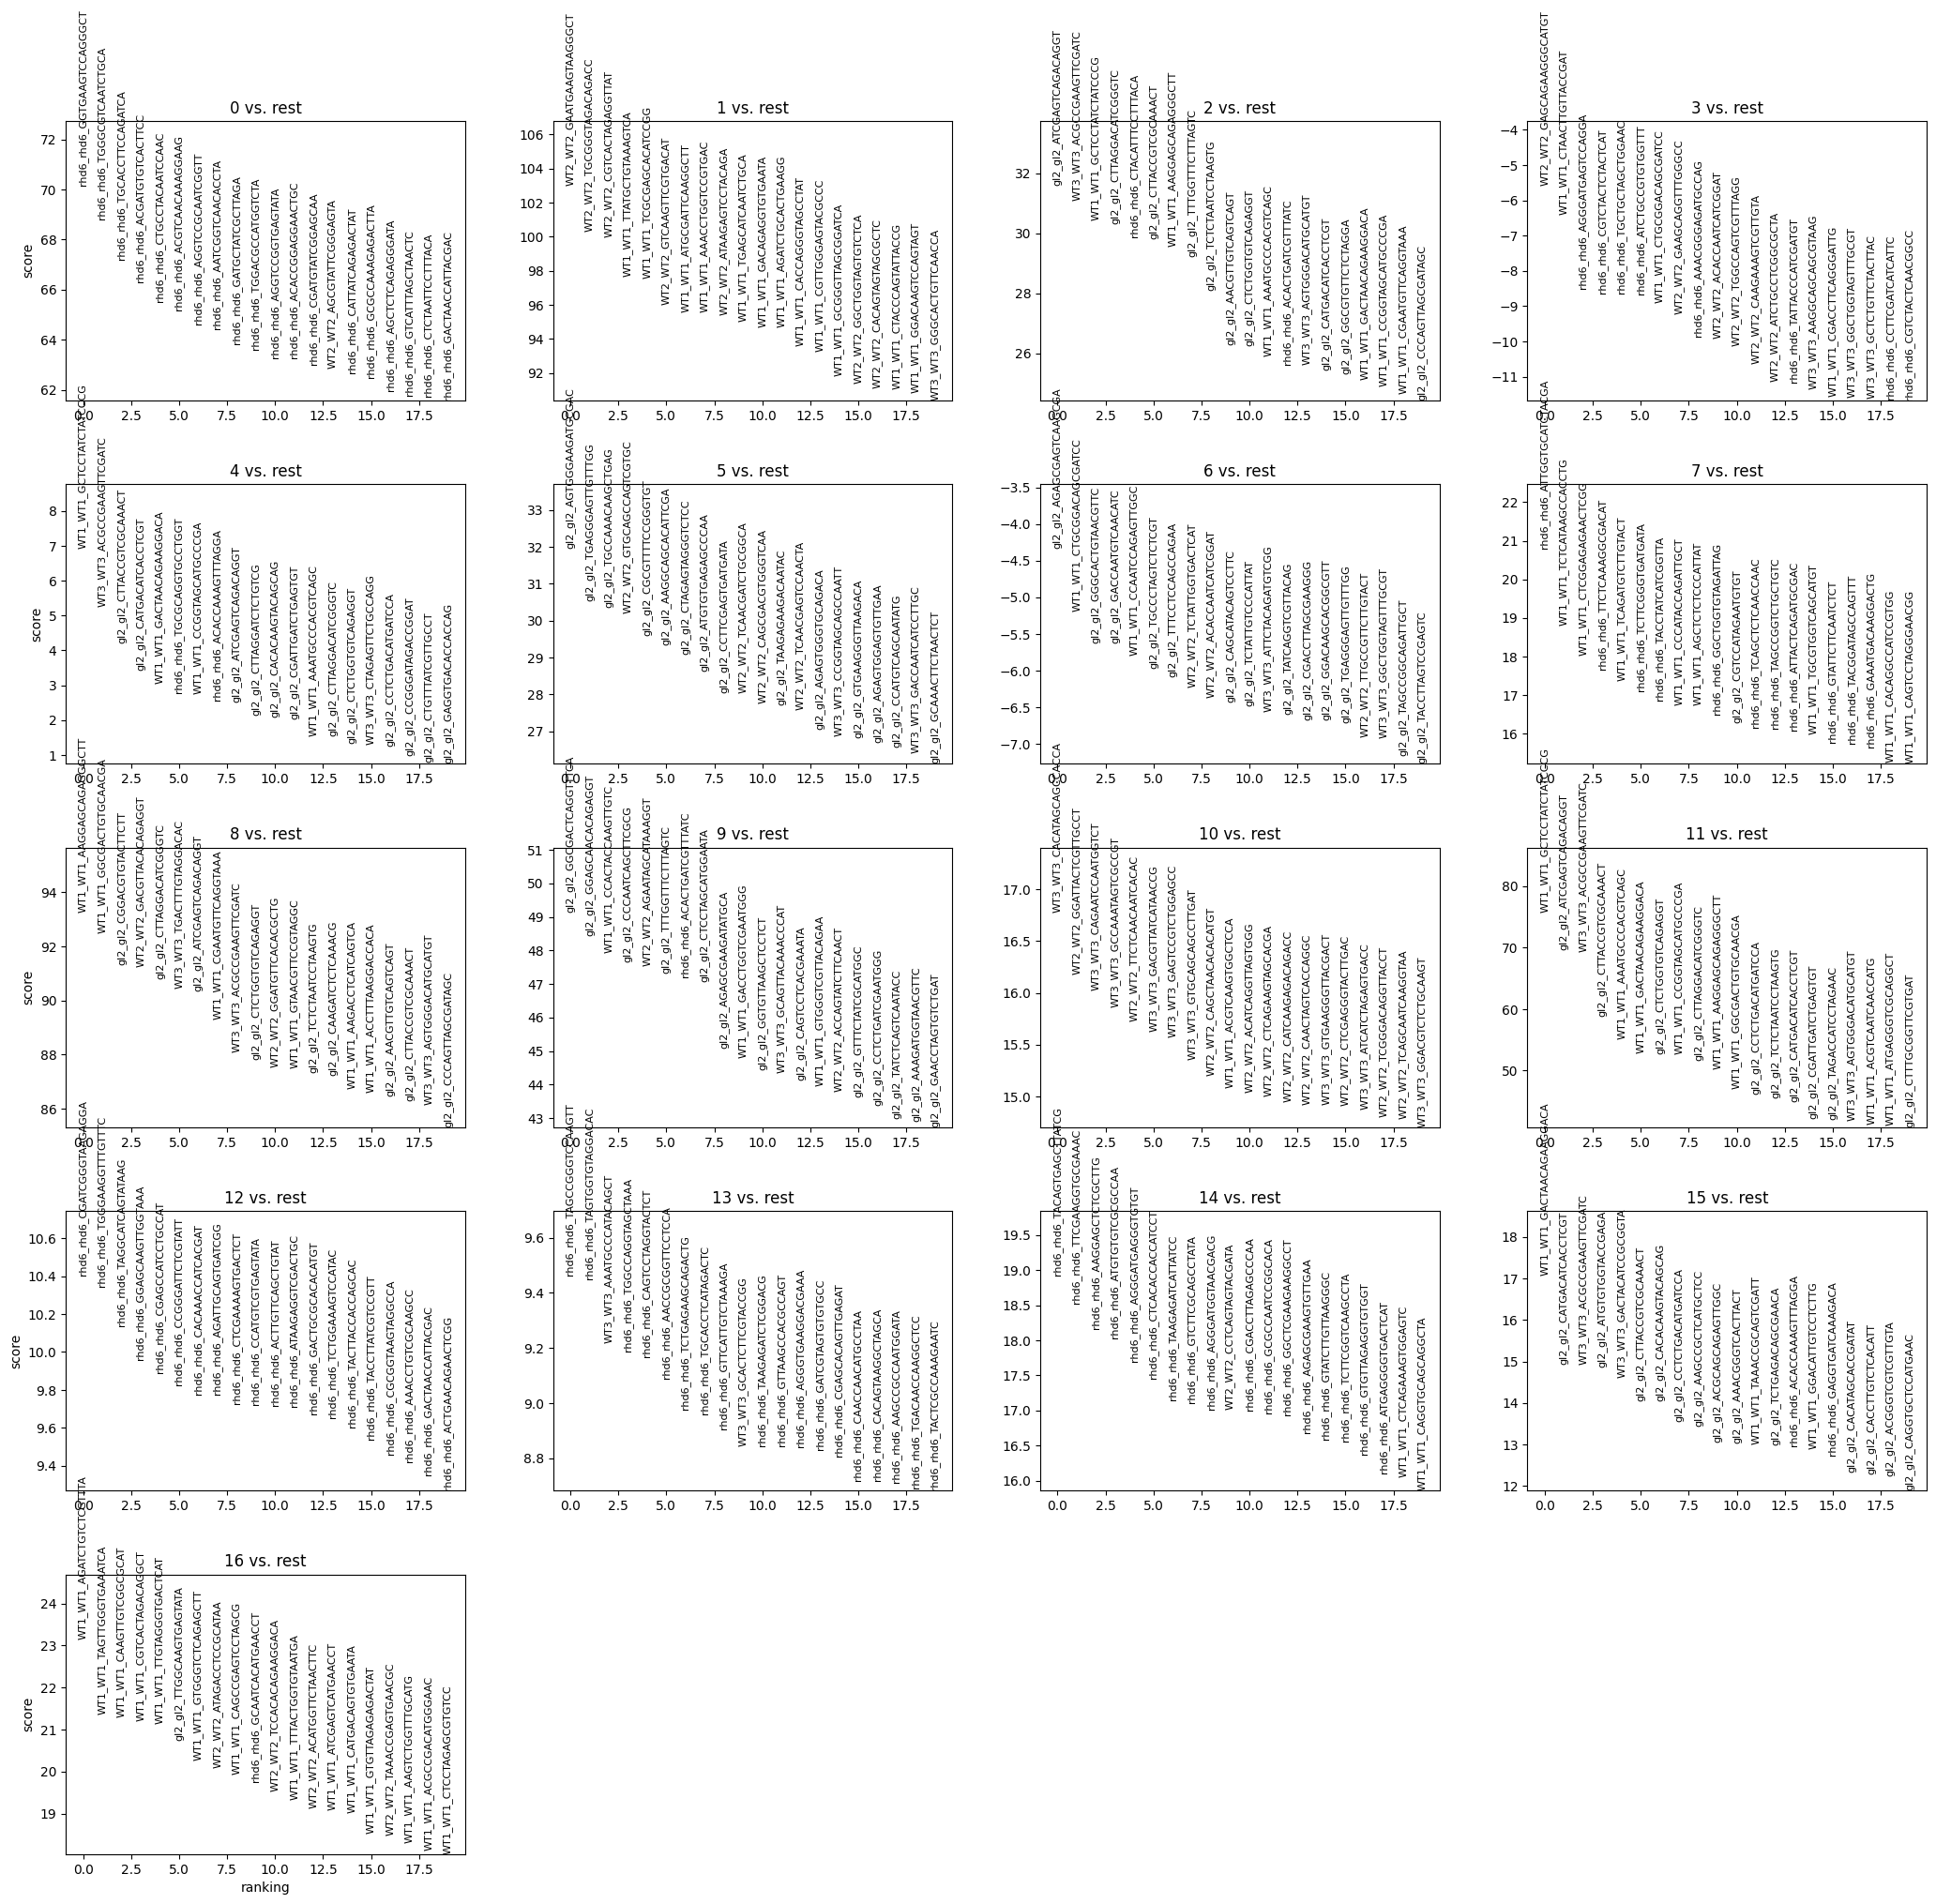

In [13]:
# Identify marker genes for each cluster using the t-test
sc.tl.rank_genes_groups(adata, 'louvain', method='t-test')

# Plot the top marker genes for each cluster
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

In [18]:
# Print the first 20 gene names to see their format
print(adata.var_names[:20])


Index(['WT1_WT1_AAACCTGAGACAGACC', 'WT1_WT1_AAACCTGAGATCCGAG',
       'WT1_WT1_AAAGCAAAGACAAGCC', 'WT1_WT1_AAAGCAAAGAGTAATC',
       'WT1_WT1_AAAGCAACACCCATTC', 'WT1_WT1_AAATGCCGTGCCTGGT',
       'WT1_WT1_AACCATGGTCCGAACC', 'WT1_WT1_AACCATGGTCTAGAGG',
       'WT1_WT1_AACTCAGCATCGGACC', 'WT1_WT1_AAGGAGCGTACTTGAC',
       'WT1_WT1_AAGGAGCTCTGGGCCA', 'WT1_WT1_AAGGTTCGTTCGCGAC',
       'WT1_WT1_AAGTCTGGTCAGATAA', 'WT1_WT1_AATCCAGGTGTTCGAT',
       'WT1_WT1_ACACCGGAGGTAGCCA', 'WT1_WT1_ACACTGAGTCTTCTCG',
       'WT1_WT1_ACATGGTGTCAAAGCG', 'WT1_WT1_ACCAGTATCAAACGGG',
       'WT1_WT1_ACCCACTGTCAACTGT', 'WT1_WT1_ACCCACTGTGCACTTA'],
      dtype='object')


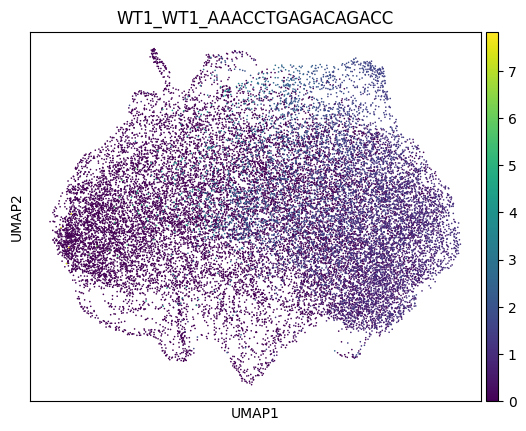

In [19]:
# Visualize the expression of one gene on UMAP
sc.pl.umap(adata, color='WT1_WT1_AAACCTGAGACAGACC')


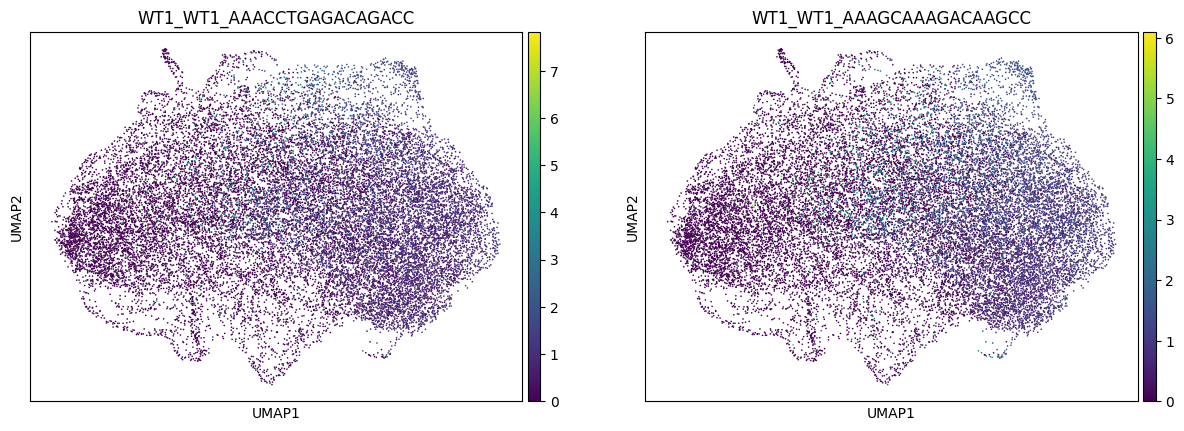

In [20]:
# Visualize multiple genes on UMAP
sc.pl.umap(adata, color=['WT1_WT1_AAACCTGAGACAGACC', 'WT1_WT1_AAAGCAAAGACAAGCC'])


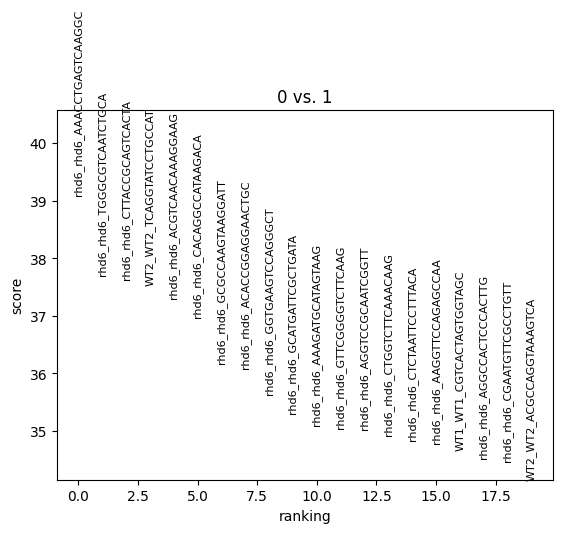

In [21]:
# Compare differential expression between two clusters
sc.tl.rank_genes_groups(adata, groupby='louvain', groups=['0'], reference='1', method='t-test')

# Plot the differential expression results
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)


In [22]:
adata.obs['cell_types'] = adata.obs['louvain'].map({
    '0': 'Root Hair Cells',
    '1': 'Cortex Cells',
    '2': 'Epidermis Cells',
    # Continue mapping based on findings
}).astype('category')

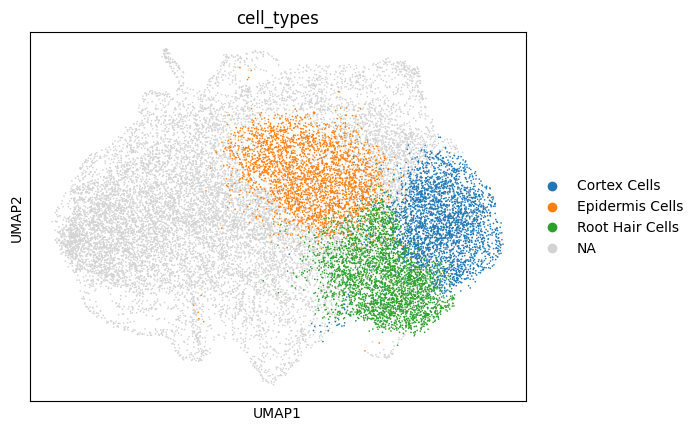

In [23]:
sc.pl.umap(adata, color='cell_types')


In [5]:
import scanpy as sc
#Save the processed data to an h5ad file
adata.write('processed_data_with_annotations.h5ad')
# Load the processed data
adata = sc.read('processed_data_with_annotations.h5ad')


/home/rushita/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


NameError: name 'adata' is not defined